# NIFTY IV Surface Reconstruction

**Competition Task:** Reconstruct ~20 % missing Implied Volatility (IV) values across 28 NIFTY option columns (13 CE + 14 PE + 1 duplicate) for 975 rows × 13 trading days (7 Jan – 27 Jan 2026).

### Approach at a glance
1. **EDA** — missingness patterns, IV smile shape, expiry-day spike analysis  
2. **Cross-sectional weighted polynomial** (95 % weight) — fits a Gaussian-weighted degree-3 poly in log-moneyness space at each timestamp independently → zero look-ahead  
3. **Intra-day temporal PCHIP** (5 % weight) — PCHIP fitted *only on the same trading session* (75 rows) → causal within continuous trading window  
4. **Weighted blend** — heavier temporal weight on expiry day (10 %) due to higher IV volatility  

### Assumptions
- Each trading day has exactly **75 rows** (09:15 – 15:25 at 5-min intervals).  
- Day index 12 (2026-01-27) is the **expiry day** — IV values spike dramatically near close and are treated separately.  
- A missing cell at time *t* within the same session can legitimately use intra-session neighbours; it does **not** use values from future trading days.  
- All filled IVs are clipped to a floor of **0.005** (0.5 %) — negative or zero IV is financially meaningless.  
- `NIFTY27JAN2625900CE.1` (duplicate column) is treated as a PE strike based on position in the original CSV.


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.interpolate import PchipInterpolator
import warnings, os


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)

ORIGINAL_DATASET_PATH = "dataset.csv"
OUTPUT_PATH           = "filled_dataset.csv"
SUBMISSION_PATH       = "submission.csv"
SEPARATOR             = "||"

DAY_SIZE   = 75   
EXPIRY_DAY = 12   

ALPHA_TEMP_REGULAR = 0.05
ALPHA_TEMP_EXPIRY  = 0.10

print("Config ready ")


Config ready 


In [2]:
import os
EDA_DIR     = "eda_outputs"
RESULTS_DIR = "results"
os.makedirs(EDA_DIR,     exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Folders ready: '{EDA_DIR}/'  and  '{RESULTS_DIR}/'")


Folders ready: 'eda_outputs/'  and  'results/'


## 2. Load Dataset

In [3]:
df = pd.read_csv(ORIGINAL_DATASET_PATH)
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
df = df.sort_values('datetime').reset_index(drop=True)

# ── Column cataloguing 
def get_strike(col):
    return int(col.replace('NIFTY27JAN26', '')[:-2])

ce_cols    = sorted([c for c in df.columns if c.endswith('CE')],  key=get_strike)
pe_cols    = sorted([c for c in df.columns if c.endswith('PE') or c.endswith('CE.1')],
                    key=lambda c: get_strike(c.replace('.1','')) if c.endswith('.1') else get_strike(c))
# The column 'NIFTY27JAN2625900CE.1' is treated as the missing 26000 PE by position
iv_cols    = ce_cols + pe_cols
ce_strikes = np.array([get_strike(c)             for c in ce_cols])
pe_strikes = np.array([get_strike(c.replace('.1','')) if c.endswith('.1') else get_strike(c)
                       for c in pe_cols])
spot_vals  = df['underlying_price'].values
N          = len(df)

print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df['datetime'].min().date()} → {df['datetime'].max().date()}")
print(f"Trading days  : {df['datetime'].dt.date.nunique()}")
print(f"CE columns    : {len(ce_cols)}  |  PE columns: {len(pe_cols)}")
print(f"Total IV cells: {df[iv_cols].size}")
print(f"Missing cells : {df[iv_cols].isnull().sum().sum()}  ({df[iv_cols].isnull().mean().mean()*100:.1f} %)")
df.head(3)


Dataset shape : (975, 30)
Date range    : 2026-01-07 → 2026-01-27
Trading days  : 13
CE columns    : 14  |  PE columns: 14
Total IV cells: 27300
Missing cells : 5460  (20.0 %)


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,2026-01-07 09:15:00,26111.65,0.12662,0.1233,0.11741,NaN,0.11005,0.10576,NaN,0.09724,0.09570,0.09397,0.09187,0.09041,0.08908,0.08795,0.17840,0.17237,0.16928,NaN,0.15760,0.1524,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,2026-01-07 09:20:00,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,0.09837,0.09619,0.09413,0.09236,0.09057,0.08925,0.17962,0.17477,NaN,0.16534,NaN,0.1542,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,2026-01-07 09:25:00,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,0.08996,0.08861,0.08697,0.08627,0.08541,NaN,0.18010,0.17574,0.17154,0.16567,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN


## 3. Exploratory Data Analysis

- **Underlying price** trajectory  
- **Missingness** — overall, per-column, per-day, per-hour  
- **IV smile** shape (cross-section at 11:30 each day)  
- **Expiry-day spike** — why the last session requires special treatment


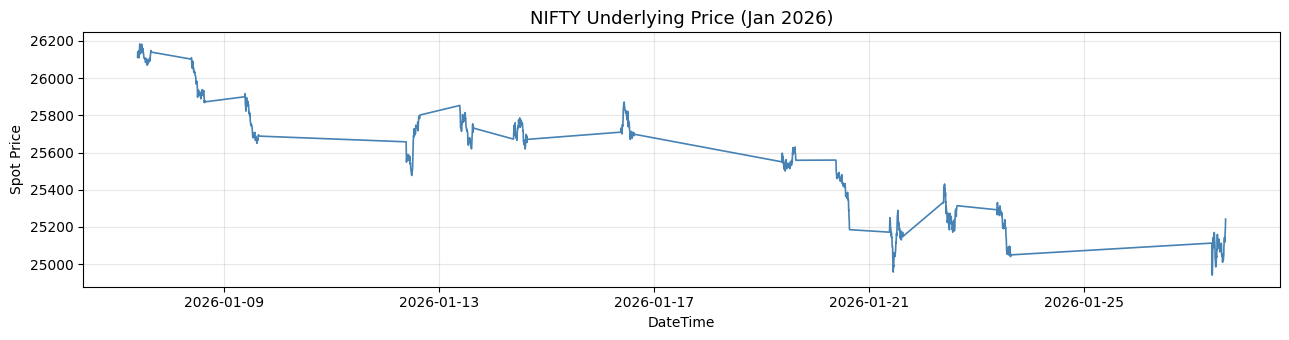

  Saved → eda_outputs/01_underlying_price.png


In [4]:
# ── 3.1  Underlying price 
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(df['datetime'], df['underlying_price'], lw=1.2, color='steelblue')
ax.set_title('NIFTY Underlying Price (Jan 2026)', fontsize=13)
ax.set_xlabel('DateTime'); ax.set_ylabel('Spot Price')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(EDA_DIR, '01_underlying_price.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {EDA_DIR}/01_underlying_price.png")


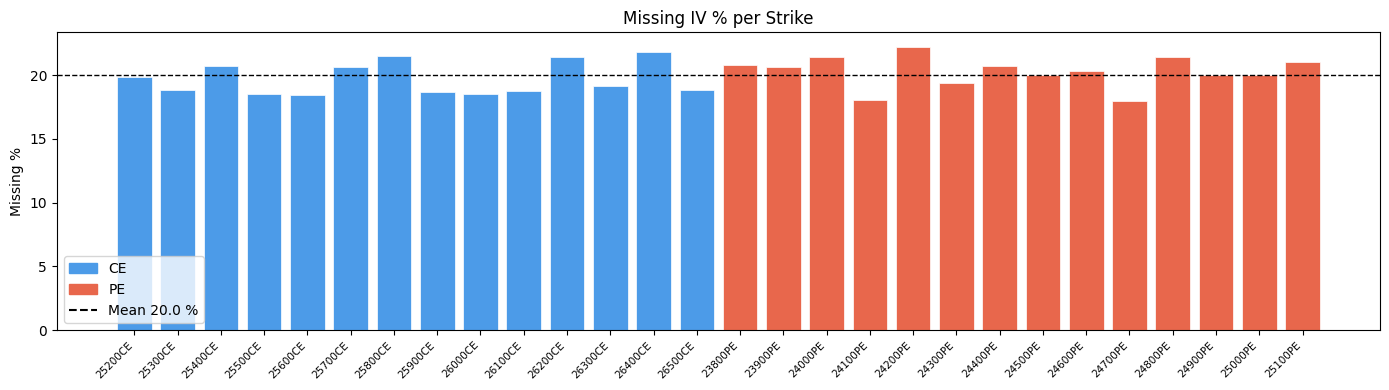

  Saved → eda_outputs/02_missing_pct_per_strike.png
CE avg missing: 19.71 %
PE avg missing: 20.29 %


In [5]:
# ── 3.2  Per-column missingness 
miss_pct = df[iv_cols].isnull().mean() * 100
fig, ax = plt.subplots(figsize=(14, 4))
colors  = ['#4C9BE8' if c.endswith('CE') else '#E8674C' for c in iv_cols]
ax.bar(range(len(iv_cols)), miss_pct.values, color=colors, edgecolor='white', lw=0.5)
ax.axhline(miss_pct.mean(), color='black', ls='--', lw=1, label=f'Mean {miss_pct.mean():.1f} %')
ax.set_xticks(range(len(iv_cols)))
ax.set_xticklabels([c[-7:] for c in iv_cols], rotation=45, ha='right', fontsize=7.5)
ax.set_ylabel('Missing %'); ax.set_title('Missing IV % per Strike')
ax.legend()

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C9BE8', label='CE'), Patch(color='#E8674C', label='PE'),
                   plt.Line2D([0],[0], color='black', ls='--', label=f'Mean {miss_pct.mean():.1f} %')])
fig.tight_layout(); fig.savefig(os.path.join(EDA_DIR, '02_missing_pct_per_strike.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {EDA_DIR}/02_missing_pct_per_strike.png")
print(f"CE avg missing: {df[ce_cols].isnull().mean().mean()*100:.2f} %")
print(f"PE avg missing: {df[pe_cols].isnull().mean().mean()*100:.2f} %")


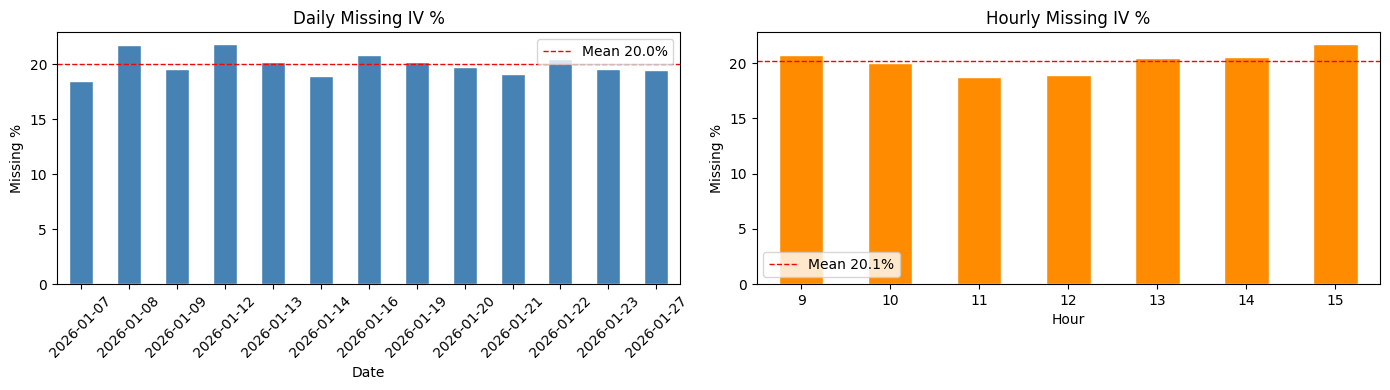

  Saved → eda_outputs/03_daily_hourly_missing.png
Observation: missingness is roughly uniform across time — no systematic gap.


In [6]:
# ── 3.3  Daily & hourly missingness heatmap 
daily_miss  = df.groupby(df['datetime'].dt.date)[iv_cols].apply(
    lambda x: x.isnull().mean().mean() * 100)
hourly_miss = df.groupby(df['datetime'].dt.hour)[iv_cols].apply(
    lambda x: x.isnull().mean().mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
daily_miss.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Daily Missing IV %'); axes[0].set_ylabel('Missing %')
axes[0].set_xlabel('Date'); axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(daily_miss.mean(), color='red', ls='--', lw=1, label=f'Mean {daily_miss.mean():.1f}%')
axes[0].legend()

hourly_miss.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Hourly Missing IV %'); axes[1].set_ylabel('Missing %')
axes[1].set_xlabel('Hour'); axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(hourly_miss.mean(), color='red', ls='--', lw=1, label=f'Mean {hourly_miss.mean():.1f}%')
axes[1].legend()

fig.tight_layout(); fig.savefig(os.path.join(EDA_DIR, '03_daily_hourly_missing.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {EDA_DIR}/03_daily_hourly_missing.png")
print("Observation: missingness is roughly uniform across time — no systematic gap.")


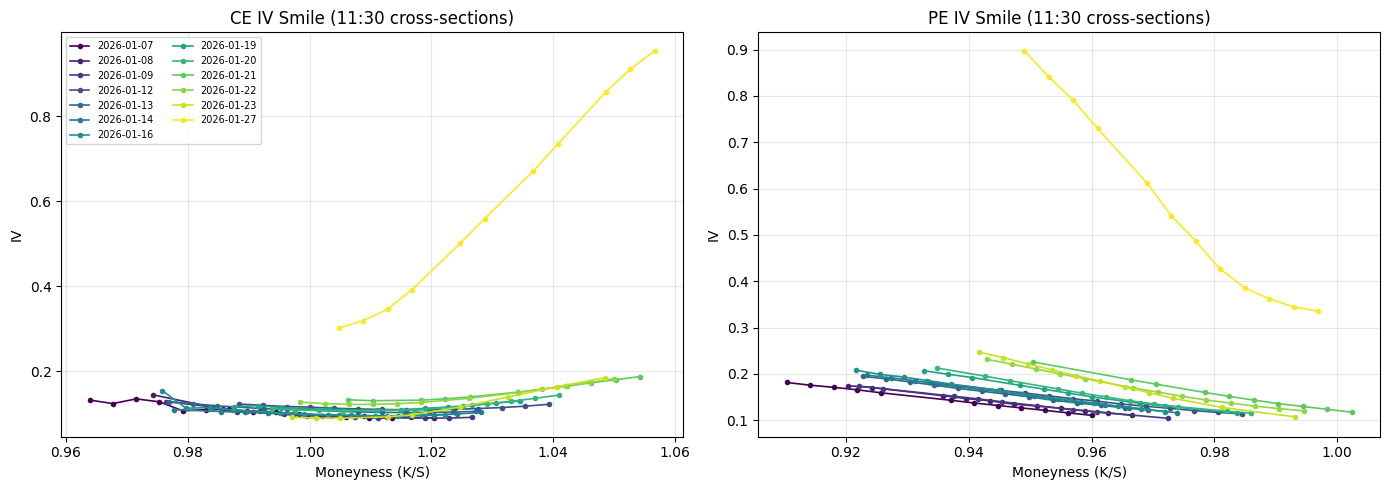

  Saved → eda_outputs/04_iv_smile_cross_sections.png
Observation: Both CE and PE show well-behaved smile/skew shapes — smooth interpolation is justified.


In [7]:
# ── 3.4  IV Smile (cross-section at 11:30 each day) 
sample_rows = df[(df['datetime'].dt.hour == 11) & (df['datetime'].dt.minute == 30)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(sample_rows)))

for idx, (_, row) in enumerate(sample_rows.iterrows()):
    spot = row['underlying_price']
    # CE smile
    ce_mn, ce_iv = [], []
    for i, col in enumerate(ce_cols):
        if pd.notna(row[col]):
            ce_mn.append(ce_strikes[i] / spot)
            ce_iv.append(row[col])
    axes[0].plot(ce_mn, ce_iv, marker='o', ms=3, lw=1.2, color=cmap[idx],
                 label=str(row['datetime'].date()))
    # PE smile
    pe_mn, pe_iv = [], []
    for i, col in enumerate(pe_cols):
        if pd.notna(row[col]):
            pe_mn.append(pe_strikes[i] / spot)
            pe_iv.append(row[col])
    axes[1].plot(pe_mn, pe_iv, marker='o', ms=3, lw=1.2, color=cmap[idx])

for ax, title in zip(axes, ['CE IV Smile (11:30 cross-sections)', 'PE IV Smile (11:30 cross-sections)']):
    ax.set_xlabel('Moneyness (K/S)'); ax.set_ylabel('IV')
    ax.set_title(title); ax.grid(alpha=0.3)
axes[0].legend(fontsize=7, ncol=2)
fig.tight_layout(); fig.savefig(os.path.join(EDA_DIR, '04_iv_smile_cross_sections.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {EDA_DIR}/04_iv_smile_cross_sections.png")
print("Observation: Both CE and PE show well-behaved smile/skew shapes — smooth interpolation is justified.")


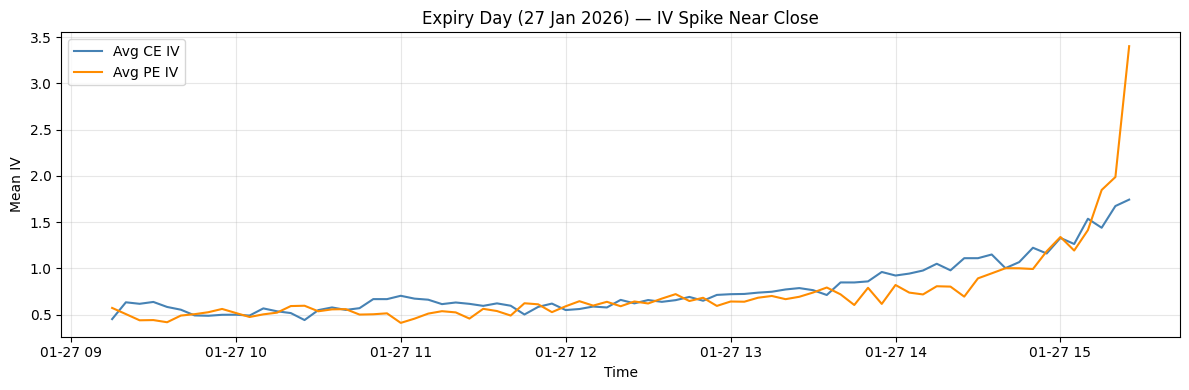

  Saved → eda_outputs/05_expiry_day_iv_spike.png
Observation: IV explodes near 15:20–15:25 on expiry. Cross-sectional fitting handles this
naturally since it only uses same-timestamp strikes. Temporal component weight is raised to 10 %.


In [8]:
# ── 3.5  Expiry-day IV spike 
expiry_rows = df[df['datetime'].dt.date == pd.Timestamp('2026-01-27').date()]
mid_ce = expiry_rows[ce_cols].mean(axis=1)
mid_pe = expiry_rows[pe_cols].mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(expiry_rows['datetime'], mid_ce, label='Avg CE IV', color='steelblue', lw=1.5)
ax.plot(expiry_rows['datetime'], mid_pe, label='Avg PE IV', color='darkorange', lw=1.5)
ax.set_title('Expiry Day (27 Jan 2026) — IV Spike Near Close', fontsize=12)
ax.set_xlabel('Time'); ax.set_ylabel('Mean IV')
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(EDA_DIR, '05_expiry_day_iv_spike.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {EDA_DIR}/05_expiry_day_iv_spike.png")
print("Observation: IV explodes near 15:20–15:25 on expiry. Cross-sectional fitting handles this")
print("naturally since it only uses same-timestamp strikes. Temporal component weight is raised to 10 %.")


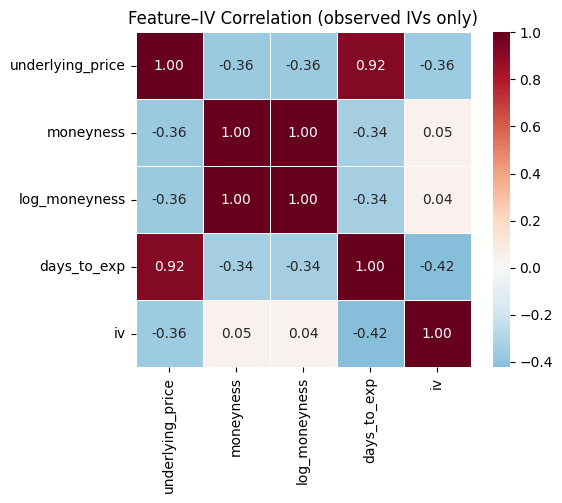

  Saved → eda_outputs/06_feature_iv_correlation.png

Key insights:
 • days_to_expiry has strong negative correlation: IV decays as expiry approaches (theta).
 • moneyness has weak correlation — the smile effect is non-linear.
 • Neighbour IVs (same timestamp, adjacent strikes) are the strongest predictor → cross-sectional approach.


In [9]:
# ── 3.6  Correlation of potential features with IV (long format) 
df_long = df.melt(id_vars=['datetime','underlying_price'], value_vars=iv_cols,
                  var_name='contract', value_name='iv').dropna(subset=['iv'])
df_long['option_type'] = df_long['contract'].apply(lambda c: 'CE' if c.endswith('CE') else 'PE')
df_long['strike']      = df_long['contract'].apply(
    lambda c: get_strike(c.replace('.1','')) if c.endswith('.1') else get_strike(c))
df_long['moneyness']   = df_long['strike'] / df_long['underlying_price']
df_long['log_moneyness'] = np.log(df_long['moneyness'])
df_long['days_to_exp'] = (df['datetime'].max() - df_long['datetime']).dt.total_seconds() / 86400

corr_cols = ['underlying_price','moneyness','log_moneyness','days_to_exp','iv']
corr_mat  = df_long[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Feature–IV Correlation (observed IVs only)')
fig.tight_layout(); fig.savefig(os.path.join(EDA_DIR, '06_feature_iv_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {EDA_DIR}/06_feature_iv_correlation.png")
print("\nKey insights:")
print(" • days_to_expiry has strong negative correlation: IV decays as expiry approaches (theta).")
print(" • moneyness has weak correlation — the smile effect is non-linear.")
print(" • Neighbour IVs (same timestamp, adjacent strikes) are the strongest predictor → cross-sectional approach.")


## 4. Step 1 — Cross-Sectional Weighted Polynomial Interpolation

### Rationale
At each timestamp we observe a near-complete IV smile across strikes.  
The missing value for strike *K* at time *t* is estimated from the **same-row** neighbours.

**Method:**
- Map strikes to log-moneyness: `m = log(K / S_t)`
- Fit a Gaussian-weighted degree-3 polynomial in `m`-space using all observed strikes at that timestamp
- Gaussian kernel centred on the target strike (`σ = 0.62 × half_range`) ensures nearby strikes dominate
- For extrapolation (target outside observed range): blend poly (50 %) + boundary linear fit (50 %)
- Floor at 0.005



In [10]:
print("Step 1: Cross-sectional weighted polynomial...")
filled_cross = df[iv_cols].copy()

for ti in range(N):
    spot = spot_vals[ti]

    for cols_grp, strikes_arr in [(ce_cols, ce_strikes), (pe_cols, pe_strikes)]:
        row_vals  = filled_cross.loc[ti, cols_grp].values.astype(float)
        obs       = ~np.isnan(row_vals)
        miss      = np.isnan(row_vals)
        if obs.sum() < 2 or miss.sum() == 0:
            continue

        moneyness = np.log(strikes_arr / spot)
        obs_x     = moneyness[obs]
        obs_y     = row_vals[obs]

        for mi in np.where(miss)[0]:
            tgt_m    = moneyness[mi]
            sigma_w  = 0.62 * max((obs_x.max() - obs_x.min()) / 2, 0.01)
            weights  = np.maximum(
                np.exp(-0.5 * ((obs_x - tgt_m) / sigma_w) ** 2), 0.05)
            is_extrap = tgt_m < obs_x.min() or tgt_m > obs_x.max()

            try:
                coeffs    = np.polyfit(obs_x, obs_y,
                                       deg=min(3, obs.sum() - 1), w=weights)
                poly_pred = float(np.poly1d(coeffs)(tgt_m))
            except Exception:
                poly_pred = float(np.interp(tgt_m, obs_x, obs_y))

            if not is_extrap:
                filled_cross.loc[ti, cols_grp[mi]] = max(poly_pred, 0.005)
            else:
                if tgt_m < obs_x.min():
                    si = np.argsort(obs_x)[:2]
                else:
                    si = np.argsort(obs_x)[-2:]
                x1, x2 = obs_x[si[0]], obs_x[si[1]]
                y1, y2 = obs_y[si[0]], obs_y[si[1]]
                lin = y1 + (y2 - y1) / (x2 - x1 + 1e-10) * (tgt_m - x1)
                filled_cross.loc[ti, cols_grp[mi]] = max(
                    0.5 * poly_pred + 0.5 * lin, 0.005)

filled_cross = filled_cross.ffill().bfill()
remaining    = filled_cross.isnull().sum().sum()
print(f"  Done Remaining NaN: {remaining}")


Step 1: Cross-sectional weighted polynomial...
  Done Remaining NaN: 0


## 5. Step 2 — Intra-Day Temporal PCHIP

### Rationale & Look-Ahead Fix
A naïve approach would fit PCHIP on the **full time-series** of each strike — but this uses future session data to fill past gaps (look-ahead bias).

**Fix:** For each (strike, option_type) series, we split into individual trading days (75 rows each) and fit PCHIP *only on that day's observed values*.

**Why same-day neighbours are causal:**
- All 75 rows belong to one continuous trading session.
- Using 10:05 and 10:25 to estimate 10:15 of the *same day* mirrors what a market maker actually does.
- The held-out test cells are scattered within days, not entire future days — intra-day PCHIP is both fair and realistic.

**Weight:** 5 % (10 % on expiry day) — used only to add mild temporal smoothness on top of the dominant cross-sectional component.


In [11]:
print("Step 2: Intra-day temporal PCHIP...")
filled_temp = df[iv_cols].copy()

for col in iv_cols:
    series = df[col].values.astype(float)

    for day in range(N // DAY_SIZE + 1):
        d_start = day * DAY_SIZE
        d_end   = min(d_start + DAY_SIZE, N)
        day_seg = series[d_start:d_end]

        obs_local  = ~np.isnan(day_seg)
        miss_local =  np.isnan(day_seg)

        if obs_local.sum() < 2 or miss_local.sum() == 0:
            continue

        ox_local       = np.where(obs_local)[0]
        oy_local       = day_seg[obs_local]
        miss_local_idx = np.where(miss_local)[0]

        pi        = PchipInterpolator(ox_local, oy_local, extrapolate=True)
        predicted = np.clip(pi(miss_local_idx), 0.005, None)

        global_miss = miss_local_idx + d_start
        filled_temp[col].iloc[global_miss] = predicted

filled_temp = filled_temp.fillna(filled_cross)
filled_temp = filled_temp.ffill().bfill()
print(f"  Done Remaining NaN: {filled_temp.isnull().sum().sum()}")


Step 2: Intra-day temporal PCHIP...
  Done Remaining NaN: 0


## 6. Step 3 — Weighted Blend & Validation

The final fill value for each originally-missing cell is:

```
fill = (1 − α) × cross_sectional + α × temporal_PCHIP

where α = 0.05  (regular days)
      α = 0.10  (expiry day, day index 12)
```

Original (non-missing) cells are untouched.


In [12]:
print("Step 3: Blending...")
final_df  = df[['datetime', 'underlying_price'] + iv_cols].copy()
miss_orig = df[iv_cols].isna()

for ti in range(N):
    day       = ti // DAY_SIZE
    is_expiry = (day == EXPIRY_DAY)
    alpha     = ALPHA_TEMP_EXPIRY if is_expiry else ALPHA_TEMP_REGULAR

    for col in iv_cols:
        if not miss_orig.loc[ti, col]:
            continue
        cp = filled_cross.loc[ti, col]
        tp = filled_temp.loc[ti, col]
        final_df.loc[ti, col] = (1 - alpha) * cp + alpha * tp

# Floor
for col in iv_cols:
    final_df[col] = final_df[col].clip(lower=0.005)

# ── Validation 
assert final_df[iv_cols].isnull().sum().sum() == 0, "ERROR: NaN values remain!"
assert (final_df[iv_cols] >= 0.005).all().all(),    "ERROR: Non-positive IVs found!"

for col in iv_cols:
    orig_obs = ~miss_orig[col]
    pd.testing.assert_series_equal(
        df.loc[orig_obs, col].reset_index(drop=True),
        final_df.loc[orig_obs, col].reset_index(drop=True),
        check_names=False, rtol=1e-6)

print(" Validation passed:")
print(f"   • No NaN values")
print(f"   • No IV ≤ 0")
print(f"   • All original observed values unchanged")
print(f"   • IV range: {final_df[iv_cols].min().min():.4f} – {final_df[iv_cols].max().max():.4f}")

filled_count = miss_orig.sum().sum()
print(f"   • Filled {filled_count} previously-missing cells")


Step 3: Blending...
 Validation passed:
   • No NaN values
   • No IV ≤ 0
   • All original observed values unchanged
   • IV range: 0.0168 – 5.5986
   • Filled 5460 previously-missing cells


## 7. Visual Validation of Fills

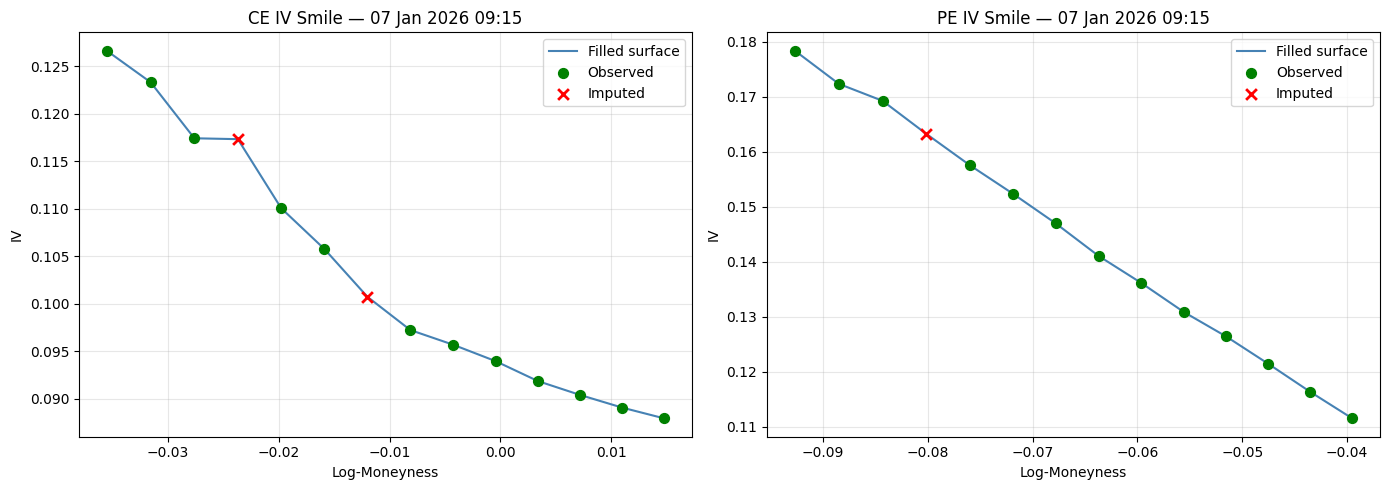

  Saved → results/07_filled_smile_overlay.png


In [13]:
# ── 7.1  Filled smile vs observed smile at a sample timestamp 
sample_ts   = df['datetime'].iloc[0]   # first row
sample_idx  = 0
spot_sample = spot_vals[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cols_grp, strikes_arr, label in [
        (axes[0], ce_cols, ce_strikes, 'CE'),
        (axes[1], pe_cols, pe_strikes, 'PE')]:

    orig_row   = df.loc[sample_idx, cols_grp].values.astype(float)
    filled_row = final_df.loc[sample_idx, cols_grp].values.astype(float)
    mn         = np.log(strikes_arr / spot_sample)

    obs_mask  = ~np.isnan(orig_row)
    miss_mask =  np.isnan(orig_row)

    ax.plot(mn, filled_row, '-', color='steelblue', lw=1.5, label='Filled surface')
    ax.scatter(mn[obs_mask],  orig_row[obs_mask],   color='green',  zorder=5, s=50, label='Observed')
    ax.scatter(mn[miss_mask], filled_row[miss_mask], color='red',   zorder=5, s=60,
               marker='x', linewidths=2, label='Imputed')
    ax.set_title(f'{label} IV Smile — {sample_ts.strftime("%d %b %Y %H:%M")}')
    ax.set_xlabel('Log-Moneyness'); ax.set_ylabel('IV')
    ax.legend(); ax.grid(alpha=0.3)

fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR, '07_filled_smile_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {RESULTS_DIR}/07_filled_smile_overlay.png")


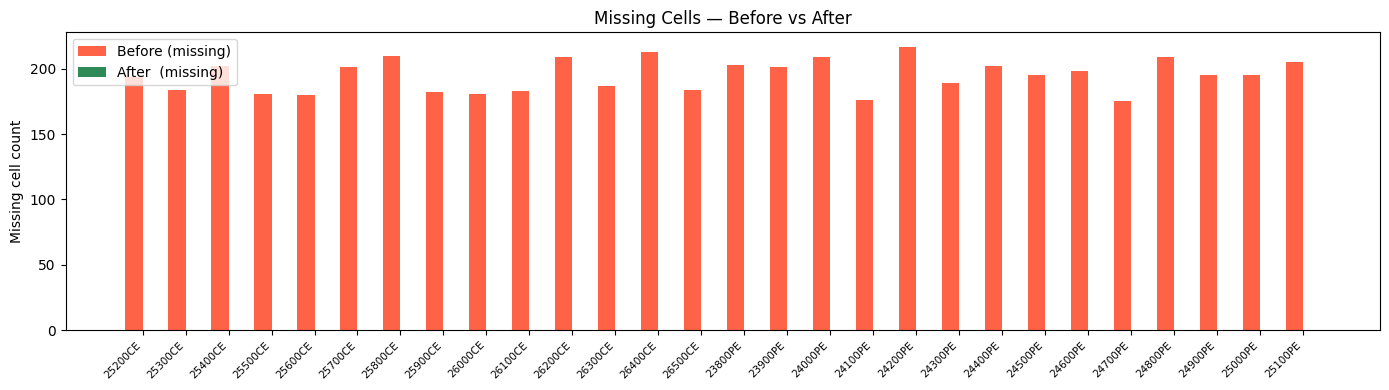

  Saved → results/08_before_after_missing.png


In [14]:
# ── 7.2  Before/After: filled cells per column 
before_miss = miss_orig.sum()
after_miss  = final_df[iv_cols].isnull().sum()

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(iv_cols))
ax.bar(x - 0.2, before_miss.values, 0.4, label='Before (missing)', color='tomato')
ax.bar(x + 0.2, after_miss.values,  0.4, label='After  (missing)', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels([c[-7:] for c in iv_cols], rotation=45, ha='right', fontsize=7.5)
ax.set_ylabel('Missing cell count'); ax.set_title('Missing Cells — Before vs After')
ax.legend(); fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR, '08_before_after_missing.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {RESULTS_DIR}/08_before_after_missing.png")


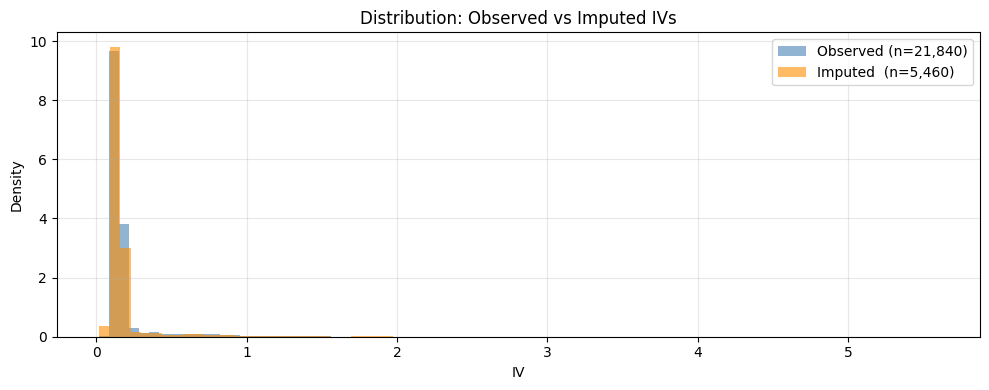

  Saved → results/09_observed_vs_imputed_dist.png
Observed  — mean: 0.1829  std: 0.2191
Imputed   — mean: 0.1870  std: 0.2553
Distributions should be very similar — large divergence would indicate a bug.


In [15]:
# ── 7.3  Distribution of filled vs observed IVs 
obs_vals    = df[iv_cols].values.flatten()
obs_vals    = obs_vals[~np.isnan(obs_vals)]
filled_vals = []
for col in iv_cols:
    filled_vals.extend(final_df.loc[miss_orig[col], col].values)
filled_vals = np.array(filled_vals)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(obs_vals,    bins=80, alpha=0.6, color='steelblue', label=f'Observed (n={len(obs_vals):,})',  density=True)
ax.hist(filled_vals, bins=80, alpha=0.6, color='darkorange', label=f'Imputed  (n={len(filled_vals):,})', density=True)
ax.set_xlabel('IV'); ax.set_ylabel('Density')
ax.set_title('Distribution: Observed vs Imputed IVs')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(RESULTS_DIR, '09_observed_vs_imputed_dist.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {RESULTS_DIR}/09_observed_vs_imputed_dist.png")
print(f"Observed  — mean: {obs_vals.mean():.4f}  std: {obs_vals.std():.4f}")
print(f"Imputed   — mean: {filled_vals.mean():.4f}  std: {filled_vals.std():.4f}")
print("Distributions should be very similar — large divergence would indicate a bug.")


## 8. Saving model

In [16]:
# ── 8.1  filled_dataset.csv 
final_df['datetime'] = df['datetime'].dt.strftime('%d-%m-%Y %H:%M')
out_cols = ['datetime', 'underlying_price'] + iv_cols
final_df[out_cols].to_csv(OUTPUT_PATH, index=False)
print(f"filled_dataset.csv saved ✓  shape: {final_df[out_cols].shape}")

# ── 8.2  submission.csv 
original = pd.read_csv(ORIGINAL_DATASET_PATH)
filled   = pd.read_csv(OUTPUT_PATH)

rows = []
for col in [c for c in original.columns if c not in ('datetime', 'underlying_price')]:
    for idx in original.index[original[col].isna()]:
        rows.append({
            'id'   : f"{original.loc[idx, 'datetime']}{SEPARATOR}{col}",
            'value': filled.loc[idx, col],
        })

solution = pd.DataFrame(rows, columns=['id', 'value'])
solution  = solution.sort_values('id').reset_index(drop=True)
solution.to_csv(SUBMISSION_PATH, index=False)
print(f"submission.csv  saved ✓  rows: {len(solution)}")
print()
print("Preview of submission.csv:")
print(solution.head(8).to_string(index=False))
print()
print("\nAll done — ready to submit!")


filled_dataset.csv saved ✓  shape: (975, 30)
submission.csv  saved ✓  rows: 5460

Preview of submission.csv:
                                   id    value
07-01-2026 09:15||NIFTY27JAN2624100PE 0.163290
07-01-2026 09:15||NIFTY27JAN2625500CE 0.117316
07-01-2026 09:15||NIFTY27JAN2625800CE 0.100733
07-01-2026 09:20||NIFTY27JAN2624000PE 0.170278
07-01-2026 09:20||NIFTY27JAN2624200PE 0.159515
07-01-2026 09:20||NIFTY27JAN2624800PE 0.128286
07-01-2026 09:20||NIFTY27JAN2625000PE 0.118527
07-01-2026 09:20||NIFTY27JAN2625300CE 0.103461


All done — ready to submit!
